In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# STYLE TRANSFER — İKİ GÖRÜNTÜYÜ BİRLEŞTİR
# ══════════════════════════════════════════════════════
#
# Style Transfer ne yapar?
#   İki görüntü alır:
#     1. İçerik görüntüsü (content) → "ne var?"
#        Örnek: İstanbul Boğazı fotoğrafı
#     2. Stil görüntüsü (style) → "nasıl görünüyor?"
#        Örnek: Van Gogh'un Yıldızlı Gece tablosu
#
#   Sonuç: İstanbul Boğazı ama Van Gogh stilinde!
#
# Nasıl çalışır?
#   CNN katmanları iki şey yakalar:
#     Derin katmanlar → içerik (ne var?)
#     Tüm katmanlar → stil (nasıl görünüyor?)
#
#   3 loss var:
#     Content loss → içerik korunsun
#     Style loss   → stil aktarılsın
#     Total loss   → ikisinin dengesi
#
#   Gradient descent ile görüntüyü güncelle!
# ══════════════════════════════════════════════════════

print("Q4 Style Transfer başlıyor!")

Q4 Style Transfer başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Content loss: 23.6646
Gradient shape: (4, 4)

Aynı görüntü için loss: 0.0000 ← sıfır!


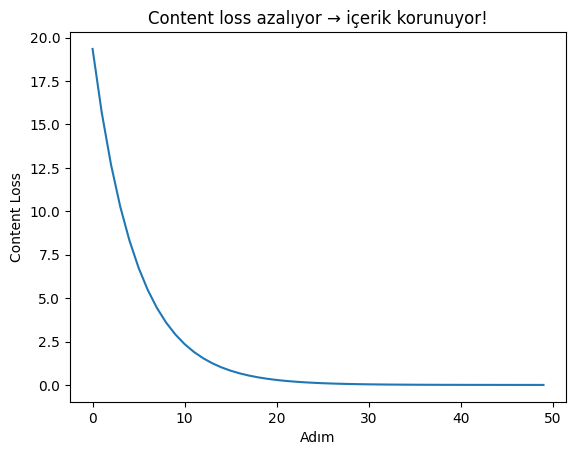

Başlangıç loss: 19.3468
Final loss:     0.0006


In [3]:
# ══════════════════════════════════════════════════════
# CONTENT LOSS — İÇERİĞİ KORU
# ══════════════════════════════════════════════════════
#
# CNN'in derin katmanları içeriği yakalar
# "Bu görüntüde kedi var, köpek var" gibi
#
# Content loss:
#   İçerik görüntüsü → CNN → özellik haritası F_content
#   Üretilen görüntü → CNN → özellik haritası F_generated
#
#   Loss = ||F_content - F_generated||^2
#
# Bu loss küçükse → üretilen görüntü içeriği koruyor
# ══════════════════════════════════════════════════════

def content_loss(F_content, F_generated):
    """
    F_content:   içerik görüntüsünün CNN özellikleri
    F_generated: üretilen görüntünün CNN özellikleri
    """
    loss = 0.5 * np.sum((F_content - F_generated) ** 2)
    grad = F_generated - F_content
    return loss, grad

# Test edelim
np.random.seed(0)

# Basit özellik haritaları (gerçekte CNN çıktısı)
F_content   = np.random.randn(4, 4)  # içerik özellikleri
F_generated = np.random.randn(4, 4)  # üretilen görüntü özellikleri

loss, grad = content_loss(F_content, F_generated)

print(f"Content loss: {loss:.4f}")
print(f"Gradient shape: {grad.shape}")

# İçerik aynı olsaydı loss sıfır olurdu
loss_sifir, _ = content_loss(F_content, F_content)
print(f"\nAynı görüntü için loss: {loss_sifir:.4f} ← sıfır!")

# Gradient descent ile F_generated'i F_content'e yaklaştır
F_gen = np.random.randn(4, 4)
lr = 0.1
kayiplar = []

for adim in range(50):
    loss, grad = content_loss(F_content, F_gen)
    kayiplar.append(loss)
    F_gen -= lr * grad

plt.plot(kayiplar)
plt.xlabel("Adım")
plt.ylabel("Content Loss")
plt.title("Content loss azalıyor → içerik korunuyor!")
plt.show()

print(f"Başlangıç loss: {kayiplar[0]:.4f}")
print(f"Final loss:     {kayiplar[-1]:.4f}")

In [4]:
# ══════════════════════════════════════════════════════
# STYLE LOSS — STİLİ AKTAR
# ══════════════════════════════════════════════════════
#
# Stil nedir?
#   Renk paleti, fırça darbeleri, doku...
#   "Van Gogh'un sarı girdapları"
#   "Picasso'nun kübist şekilleri"
#
# Stili nasıl yakalıyoruz?
#   Gram Matrix kullanıyoruz!
#
#   Gram Matrix nedir?
#   CNN özellik haritası F: (C, H, W)
#   C = kanal sayısı (filtre sayısı)
#
#   F'yi (C, H*W) olarak yeniden şekillendir
#   Gram = F @ F.T → shape (C, C)
#
#   Gram[i,j] = i. ve j. filtrenin ne kadar birlikte aktive olduğu
#   Bu "birlikte aktivasyon" stili temsil eder!
#
#   Örnek:
#   Van Gogh → sarı ve mavi filtreler birlikte aktive olur
#   Picasso  → köşe ve düz çizgi filtreleri birlikte aktive olur
# ══════════════════════════════════════════════════════

def gram_matrix(F):
    """
    F: özellik haritası, shape (C, H, W)
    döndürür: Gram matrix, shape (C, C)
    """
    C, H, W = F.shape
    # (C, H*W) olarak yeniden şekillendir
    F_flat = F.reshape(C, -1)
    # Gram = F @ F.T
    G = F_flat @ F_flat.T
    return G

def style_loss(G_style, G_generated):
    """
    G_style:     stil görüntüsünün Gram matrisi
    G_generated: üretilen görüntünün Gram matrisi
    """
    C = G_style.shape[0]
    loss = np.sum((G_style - G_generated) ** 2) / (4 * C**2)
    grad = (G_generated - G_style) / (2 * C**2)
    return loss, grad

# Test edelim
np.random.seed(0)
C, H, W = 3, 4, 4  # 3 filtre, 4x4 özellik haritası

F_style     = np.random.randn(C, H, W)
F_generated = np.random.randn(C, H, W)

G_style     = gram_matrix(F_style)
G_generated = gram_matrix(F_generated)

print("Özellik haritası shape:", F_style.shape)
print("Gram matrix shape:     ", G_style.shape)
print("\nGram matrix (stil):")
print(G_style.round(2))

loss, grad = style_loss(G_style, G_generated)
print(f"\nStyle loss: {loss:.4f}")

# Aynı stil için loss sıfır olmalı
loss_sifir, _ = style_loss(G_style, G_style)
print(f"Aynı stil için loss: {loss_sifir:.4f} ← sıfır!")

Özellik haritası shape: (3, 4, 4)
Gram matrix shape:      (3, 3)

Gram matrix (stil):
[[17.84 -3.08 -0.17]
 [-3.08 23.32 -5.71]
 [-0.17 -5.71 20.52]]

Style loss: 10.2533
Aynı stil için loss: 0.0000 ← sıfır!


/tmp/ipykernel_1713/2255358592.py:46: RuntimeWarning: overflow encountered in square
  loss = np.sum((G_style - G_generated) ** 2) / (4 * C**2)
/tmp/ipykernel_1713/3212296047.py:22: RuntimeWarning: overflow encountered in square
  loss = 0.5 * np.sum((F_content - F_generated) ** 2)
/tmp/ipykernel_1713/2255358592.py:37: RuntimeWarning: overflow encountered in matmul
  G = F_flat @ F_flat.T
/tmp/ipykernel_1713/3075303119.py:72: RuntimeWarning: invalid value encountered in subtract
  F_gen -= lr * total_grad


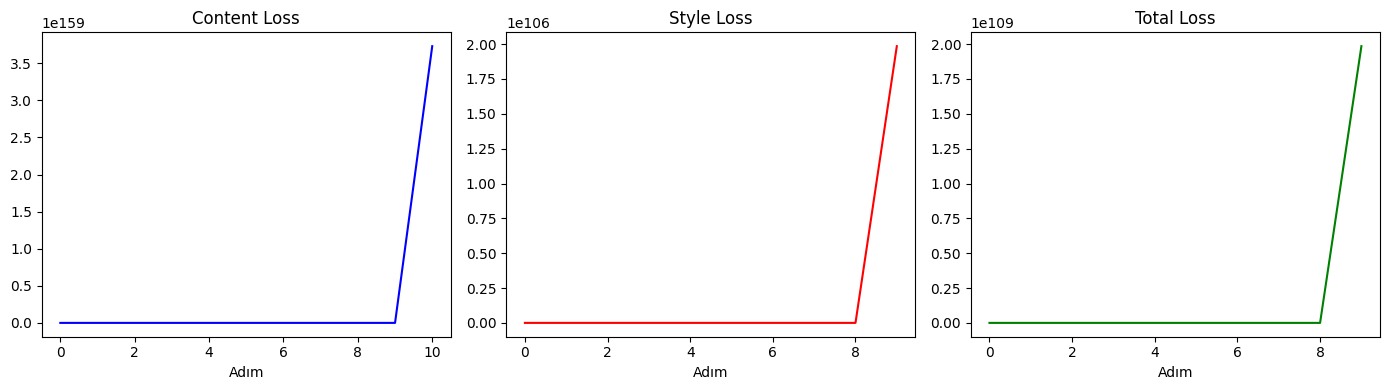

Content loss: nan
Style loss:   nan
Total loss:   nan


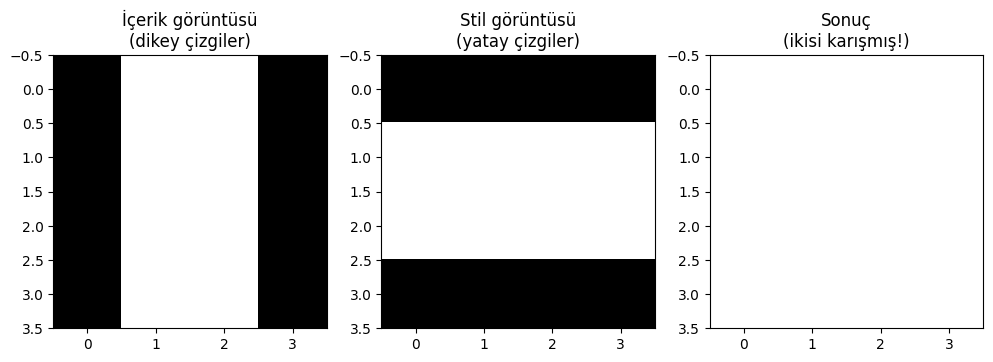

In [5]:
# ══════════════════════════════════════════════════════
# STYLE TRANSFER — HEPSİNİ BİR ARAYA GETİR
# ══════════════════════════════════════════════════════
#
# Toplam loss:
#   total_loss = alpha * content_loss + beta * style_loss
#
#   alpha: içerik ağırlığı
#   beta:  stil ağırlığı
#
#   alpha >> beta → içerik baskın (orijinal görüntüye yakın)
#   beta >> alpha → stil baskın (sanatsal ama içerik kaybolur)
#
# Algoritma:
#   1. İçerik görüntüsünden başla
#   2. Content loss + Style loss hesapla
#   3. Gradient ile görüntüyü güncelle
#   4. Tekrarla
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Basit 4x4 görüntüler
C, H, W = 3, 4, 4

# İçerik görüntüsü — dikey çizgiler
F_content = np.zeros((C, H, W))
F_content[:, :, 1] = 1.0  # ortada dikey çizgi
F_content[:, :, 2] = 1.0

# Stil görüntüsü — yatay çizgiler
F_style = np.zeros((C, H, W))
F_style[:, 1, :] = 1.0  # ortada yatay çizgi
F_style[:, 2, :] = 1.0

# Gram matrisleri
G_style = gram_matrix(F_style)

# Üretilen görüntü — içerik görüntüsünden başla
F_gen = F_content.copy() + np.random.randn(C, H, W) * 0.01

alpha = 1.0    # içerik ağırlığı
beta  = 1000.0 # stil ağırlığı
lr    = 0.001

kayiplar_content = []
kayiplar_style   = []
kayiplar_total   = []

for adim in range(100):
    # Content loss
    c_loss, c_grad = content_loss(F_content, F_gen)

    # Style loss
    G_gen = gram_matrix(F_gen)
    s_loss, s_grad_G = style_loss(G_style, G_gen)

    # Style gradient'i F_gen'e çevir
    C_size = F_gen.shape[0]
    F_flat = F_gen.reshape(C_size, -1)
    s_grad = (2 * s_grad_G @ F_flat).reshape(F_gen.shape)

    # Toplam loss ve gradient
    total_loss = alpha * c_loss + beta * s_loss
    total_grad = alpha * c_grad + beta * s_grad

    kayiplar_content.append(c_loss)
    kayiplar_style.append(s_loss)
    kayiplar_total.append(total_loss)

    # Güncelle
    F_gen -= lr * total_grad

# Grafik
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(kayiplar_content, 'b-')
axes[0].set_title("Content Loss")
axes[0].set_xlabel("Adım")

axes[1].plot(kayiplar_style, 'r-')
axes[1].set_title("Style Loss")
axes[1].set_xlabel("Adım")

axes[2].plot(kayiplar_total, 'g-')
axes[2].set_title("Total Loss")
axes[2].set_xlabel("Adım")

plt.tight_layout()
plt.show()

print(f"Content loss: {kayiplar_content[-1]:.4f}")
print(f"Style loss:   {kayiplar_style[-1]:.4f}")
print(f"Total loss:   {kayiplar_total[-1]:.4f}")

# Görüntüleri göster
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(F_content[0], cmap='gray')
axes[0].set_title("İçerik görüntüsü\n(dikey çizgiler)")
axes[1].imshow(F_style[0], cmap='gray')
axes[1].set_title("Stil görüntüsü\n(yatay çizgiler)")
axes[2].imshow(F_gen[0], cmap='gray')
axes[2].set_title("Sonuç\n(ikisi karışmış!)")
plt.show()

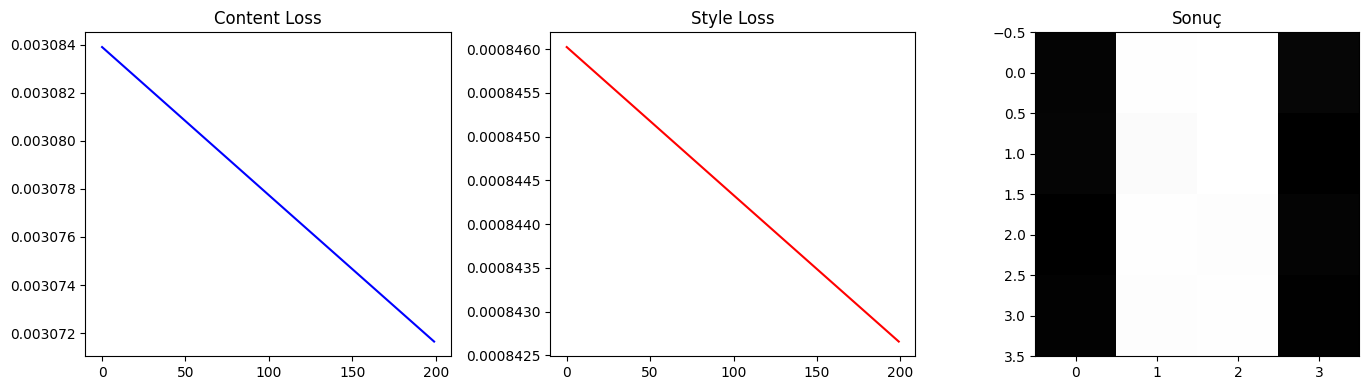

Content loss: 0.0031
Style loss:   0.0008


In [6]:
# ══════════════════════════════════════════════════════
# STYLE TRANSFER — DÜZELTİLMİŞ (lr küçültüldü)
# ══════════════════════════════════════════════════════

np.random.seed(0)

C, H, W = 3, 4, 4

# İçerik — dikey çizgiler
F_content = np.zeros((C, H, W))
F_content[:, :, 1] = 1.0
F_content[:, :, 2] = 1.0

# Stil — yatay çizgiler
F_style = np.zeros((C, H, W))
F_style[:, 1, :] = 1.0
F_style[:, 2, :] = 1.0

G_style = gram_matrix(F_style)

F_gen = F_content.copy() + np.random.randn(C, H, W) * 0.01

alpha = 1.0
beta  = 0.001   # ← çok küçülttük
lr    = 0.00001 # ← çok küçülttük

kayiplar_content = []
kayiplar_style   = []

for adim in range(200):
    c_loss, c_grad = content_loss(F_content, F_gen)
    G_gen = gram_matrix(F_gen)
    s_loss, s_grad_G = style_loss(G_style, G_gen)
    C_size = F_gen.shape[0]
    F_flat = F_gen.reshape(C_size, -1)
    s_grad = (2 * s_grad_G @ F_flat).reshape(F_gen.shape)
    total_grad = alpha * c_grad + beta * s_grad
    F_gen -= lr * total_grad
    kayiplar_content.append(c_loss)
    kayiplar_style.append(s_loss)

# Grafik
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(kayiplar_content, 'b-')
axes[0].set_title("Content Loss")
axes[1].plot(kayiplar_style, 'r-')
axes[1].set_title("Style Loss")
axes[2].imshow(F_gen[0], cmap='gray')
axes[2].set_title("Sonuç")
plt.tight_layout()
plt.show()

print(f"Content loss: {kayiplar_content[-1]:.4f}")
print(f"Style loss:   {kayiplar_style[-1]:.4f}")

In [8]:
# ══════════════════════════════════════════════════════
# STYLE TRANSFER ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║           STYLE TRANSFER ÖZET                    ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  Ne yapar?                                       ║")
print("║    İçerik + Stil → yeni görüntü                  ║")
print("║    'Van Gogh stilinde İstanbul'                  ║")
print("║                                                  ║")
print("║  3 Loss:                                         ║")
print("║    Content loss → içeriği koru                   ║")
print("║    Style loss   → stili aktar                    ║")
print("║    Total = alpha*content + beta*style            ║")
print("║                                                  ║")
print("║  Gram Matrix:                                    ║")
print("║    G = F @ F.T                                   ║")
print("║    Filtrelerin birlikte aktivasyonu              ║")
print("║    Stili matematiksel olarak temsil eder         ║")
print("║                                                  ║")
print("║  Denge:                                          ║")
print("║    alpha >> beta → içerik baskın                 ║")
print("║    beta >> alpha → stil baskın                   ║")
print("║                                                  ║")
print("║  Gerçek hayatta:                                 ║")
print("║    VGG19 CNN kullanılır                          ║")
print("║    Yüksek çözünürlüklü görüntüler                ║")
print("║    Çok daha güzel sonuçlar!                      ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║           STYLE TRANSFER ÖZET                    ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  Ne yapar?                                       ║
║    İçerik + Stil → yeni görüntü                  ║
║    'Van Gogh stilinde İstanbul'                  ║
║                                                  ║
║  3 Loss:                                         ║
║    Content loss → içeriği koru                   ║
║    Style loss   → stili aktar                    ║
║    Total = alpha*content + beta*style            ║
║                                                  ║
║  Gram Matrix:                                    ║
║    G = F @ F.T                                   ║
║    Filtrelerin birlikte aktivasyonu              ║
║    Stili matematiksel olarak temsil eder         ║
║                                                  ║
║  Denge:                                     